# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [1]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_13771/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_13771/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


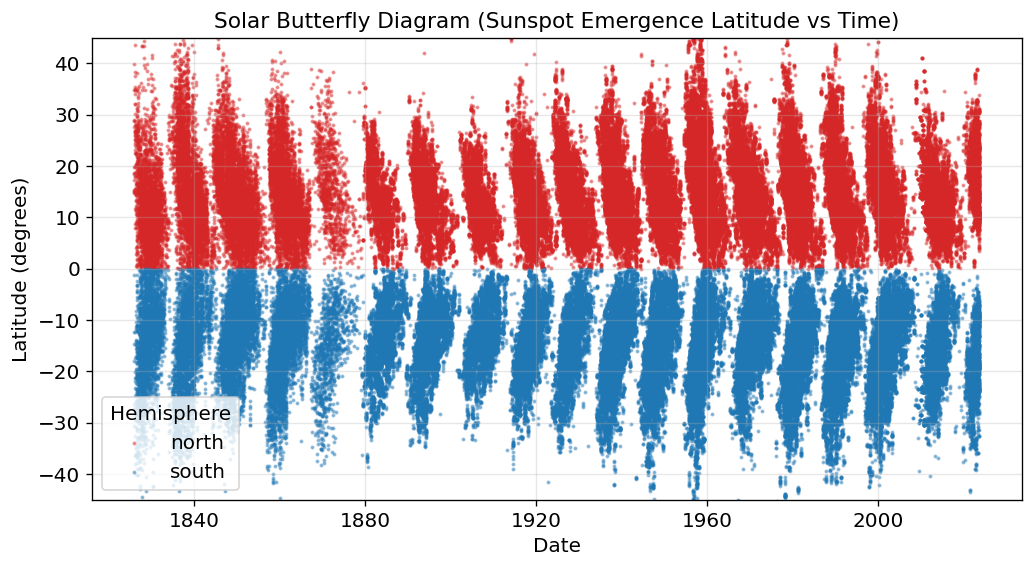

In [3]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


I used Gemini to come up with this originally but I forgot the save the conversation:

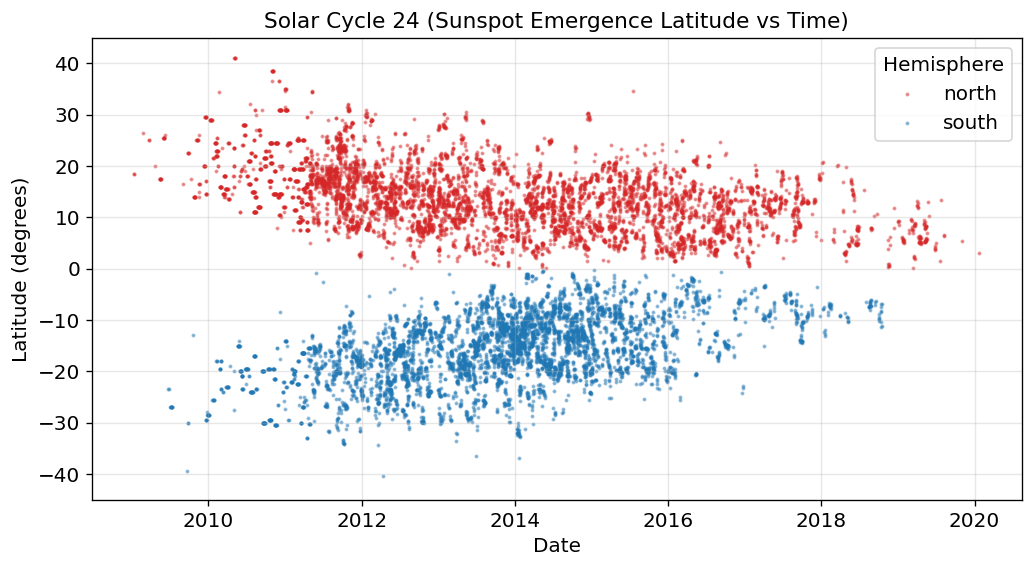

In [5]:
# Your code here: Visualize a single solar cycle
import matplotlib.pyplot as plt

df_cycle24 = df[df["CYCLE"] == 24].copy()

df_cycle24['hemisphere'] = df_cycle24['latitude'].apply(lambda v: 'north' if v >= 0 else 'south')

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle24.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Cycle 24 (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()

## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


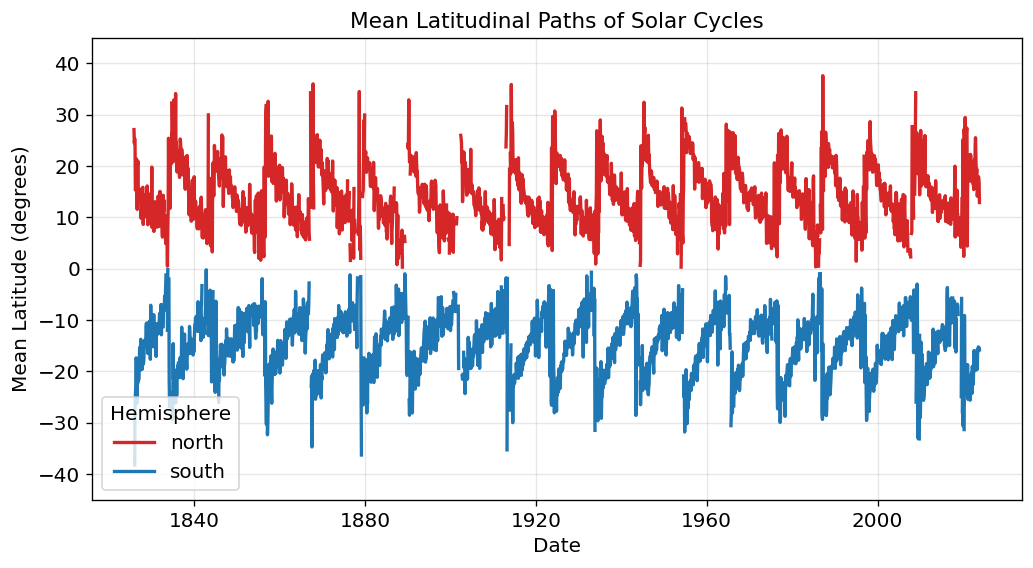

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

df_resample = df.set_index('date')

# Group by hemisphere and resample by month, then calculate the mean of latitude
# Use 'ME' for month end, as 'M' is deprecated
# Call reset_index() to convert the MultiIndex Series to a DataFrame with 'date' and 'latitude' columns
mean_lat_monthly = df_resample.groupby('hemisphere')['latitude'].resample('ME').mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in mean_lat_monthly.groupby("hemisphere"):
    # Now 'group' is a DataFrame, so we access 'date' and 'latitude' as columns
    ax.plot(group["date"], group["latitude"], color=colors[hemi], label=hemi, linewidth=2)

ax.set_title("Mean Latitudinal Paths of Solar Cycles")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.grid(True)
plt.show()

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


*Your reflection here:*
I think the most important takeaway from Gem's response is that this process will be a partnership. My goal isn't to have all the answers handed to me, but rather be guided towards solutions in a way that forces me to think. It's good to know that I can tailor the AI assistant to that goal.



Gemini's response:
That's a great question! To effectively prompt an AI assistant for learning machine learning and solar physics concepts, consider these strategies:

Be Specific with Your Goal: Clearly state what you want to learn. Instead of just "Explain machine learning," try "Explain how a Convolutional Neural Network works for image classification, assuming I have a basic understanding of linear algebra." or "Describe the physical processes that drive a solar flare and how they relate to sunspot activity."

Define Your Current Knowledge Level: Tell the AI what you already know (or don't know). This helps it tailor the explanation. For example, "Explain the concept of backpropagation in neural networks, but keep the math to a high level, as I'm new to calculus." or "I understand basic plasma physics, how does it apply to the solar corona's heating problem?"

Specify the Desired Output Format: Do you want a summary, a step-by-step guide, code examples, analogies, or a comparison? "Give me a step-by-step guide to building a simple linear regression model in Python using scikit-learn." or "Provide an analogy to explain quantum tunneling in the Sun's core."

Ask for Examples and Analogies: Concrete examples make abstract concepts easier to grasp. "Give me a real-world example of overfitting in machine learning and how regularization helps." or "Can you give me an analogy to understand magnetic reconnection in solar physics?"

Request Elaboration or Simplification: If an explanation is too complex, ask for a simpler version. If it's too basic, ask for more depth. "That explanation of gradient descent was a bit too technical. Can you simplify it for someone with no calculus background?" or "Expand on the different types of solar radiation and their effects on Earth."

Break Down Complex Questions: For very broad topics, start with a high-level overview, then dive into specifics. "What are the main branches of machine learning?" (after that) "Now, tell me more about supervised learning and its common algorithms."

Ask for Related Concepts: "What are the common metrics used to evaluate classification models?" or "What other solar phenomena are related to sunspots besides flares?"

Request Code Snippets (for ML): "Show me how to load a dataset, split it into training and testing sets, and train a RandomForestClassifier in Python." (Be specific about the libraries you want to use, e.g., scikit-learn, TensorFlow, PyTorch).

Iterate and Refine: Don't be afraid to ask follow-up questions. Learning is an iterative process. "You mentioned 'feature engineering.' What are some common techniques for that?"

By being clear, specific, and iterative, you can guide the AI to become a very effective personalized tutor!
